# EDA - AI Jobs Market

## Actividad

Realizar un EDA básico del dataset seleccionado:

Estadística descriptiva

Tipos de variables

Identificación de duplicados, nulos, outliers

Incluir al menos 3 gráficos

## Descripción del data set


1.500 ofertas laborales de inteligencia artificial y aprendizaje automático de 2025-2026, que abarca 25 puestos en 14 países.



| Columna | Descripción |
|---|---|
| `job_id` | Unique job posting identifier |
| `job_title` | Specific AI/ML role title |
| `job_category` | Role category (AI Engineering, Data Science, etc.) |
| `experience_level` | Entry / Mid / Senior / Lead |
| `years_of_experience` | Required years of experience |
| `education_required` | Minimum education level required |
| `annual_salary_usd` | Annual salary in USD |
| `salary_min_usd` | Minimum salary range for role |
| `salary_max_usd` | Maximum salary range for role |
| `city` | Job location city |
| `country` | Job location country |
| `remote_work` | On-site / Hybrid / Fully Remote |
| `company_size` | Startup / SME / Mid-size / Enterprise / Big Tech |
| `industry` | Industry sector of hiring company |
| `required_skills` | Pipe-separated list of required skills |
| `ai_salary_premium_pct` | Salary premium % vs non-AI equivalent role |
| `demand_score` | Market demand score from 0 to 100 for this role |
| `demand_growth_yoy_pct` | Year-over-year demand growth (%) |
| `benefits_score_10` | Benefits package quality score (0–10) |
| `posting_year` | Year job was posted (2025 or 2026) |
| `posting_month` | Month job was posted |
| `is_senior` | 1 if Senior or Lead level role |
| `is_remote_friendly` | 1 if Hybrid or Fully Remote |
| `is_llm_role` | 1 if role involves LLM/GenAI work |
| `salary_tier` | Entry / Mid / Upper-Mid / Senior / Elite |

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats as st

## 1. Carga y preparación de los datos

In [2]:
ruta = "ai_jobs_market_2025_2026.csv"
df = pd.read_csv(ruta)

### Se corrobora la carga de datos

In [3]:
pd.set_option("display.max_columns", None)
df.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [4]:
df.shape

(1500, 25)

In [5]:
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   str    
 1   job_title              1500 non-null   str    
 2   job_category           1500 non-null   str    
 3   experience_level       1500 non-null   str    
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   str    
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   str    
 10  country                1500 non-null   str    
 11  remote_work            1500 non-null   str    
 12  company_size           1500 non-null   str    
 13  industry               1500 non-null   str    
 14  required_skills        1500 non-null   str    
 15  ai_salary_premi

In [7]:
df.dtypes

job_id                       str
job_title                    str
job_category                 str
experience_level             str
years_of_experience        int64
education_required           str
annual_salary_usd        float64
salary_min_usd             int64
salary_max_usd             int64
city                         str
country                      str
remote_work                  str
company_size                 str
industry                     str
required_skills              str
ai_salary_premium_pct    float64
demand_score               int64
demand_growth_yoy_pct    float64
benefits_score_10        float64
posting_year               int64
posting_month              int64
is_senior                  int64
is_remote_friendly         int64
is_llm_role                int64
salary_tier                  str
dtype: object

### Conclusión inicial

El dataset fue cargado correctamente y presenta una dimensión de **1500 filas y 25 columnas**, lo que lo hace adecuado para un análisis exploratorio. La estructura general de las variables es consistente: se observan columnas categóricas en formato texto, variables numéricas enteras y variables numéricas decimales. 

No se detectan problemas evidentes en la carga ni en los tipos de datos a nivel general, aunque algunas variables binarias y temporales podrían reinterpretarse más adelante según las necesidades del análisis. 

En conjunto, la base se encuentra en buenas condiciones para avanzar con la exploración de nulos, duplicados, estadística descriptiva y visualizaciones.



## 2. Revisión de calidad de datos

### 2.1 Valores nulos

In [8]:
df.isna().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

<Axes: >

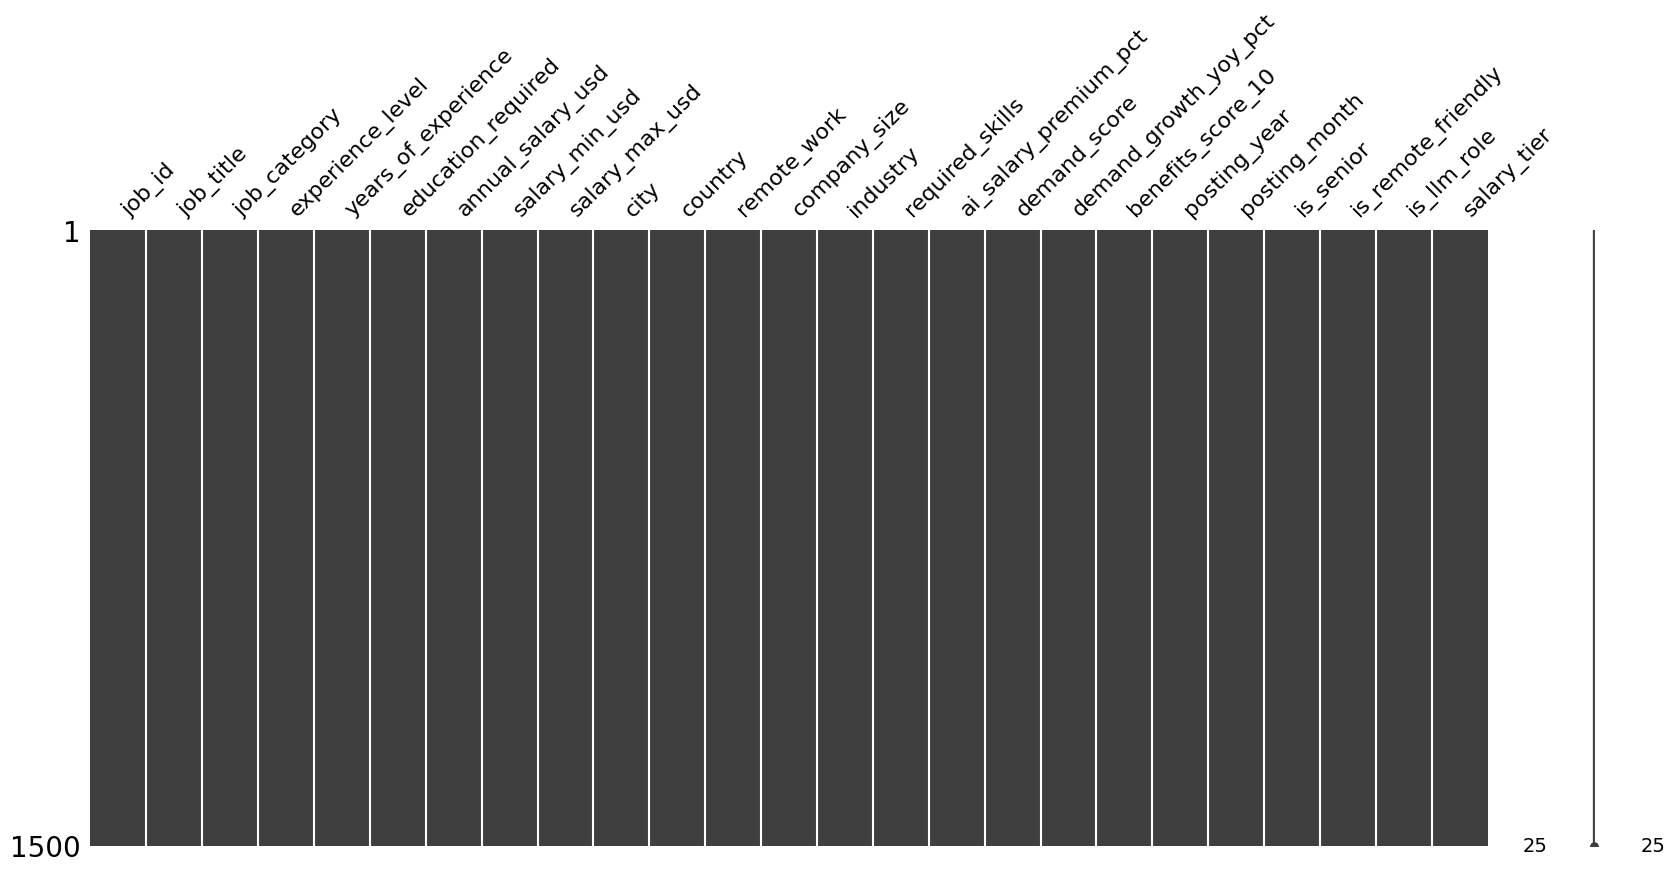

In [9]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

### 2.2 Duplicados

In [10]:
df.duplicated().sum()

np.int64(0)

### 2.3 Conclusión de la calidad

No hay datos nulos ni duplicados

## 3. Clasificación y descripción de variables

En esta sección se clasifican las variables del dataset según su naturaleza analítica, con el objetivo de distinguir entre identificadores, variables categóricas, numéricas y binarias. Esta organización permite seleccionar mejor las herramientas descriptivas y gráficas más adecuadas para cada tipo de variable.

In [11]:
df.dtypes

job_id                       str
job_title                    str
job_category                 str
experience_level             str
years_of_experience        int64
education_required           str
annual_salary_usd        float64
salary_min_usd             int64
salary_max_usd             int64
city                         str
country                      str
remote_work                  str
company_size                 str
industry                     str
required_skills              str
ai_salary_premium_pct    float64
demand_score               int64
demand_growth_yoy_pct    float64
benefits_score_10        float64
posting_year               int64
posting_month              int64
is_senior                  int64
is_remote_friendly         int64
is_llm_role                int64
salary_tier                  str
dtype: object

### Clasificación de variables según su naturaleza

#### 1. Variables cuantitativas

#### Discretas

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `years_of_experience` | `int64` | Años de experiencia requeridos |
| `salary_min_usd` | `int64` | Salario mínimo del puesto |
| `salary_max_usd` | `int64` | Salario máximo del puesto |
| `demand_score` | `int64` | Puntaje de demanda del rol |

#### Continuas

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `annual_salary_usd` | `float64` | Salario anual en USD |
| `ai_salary_premium_pct` | `float64` | Prima salarial de AI respecto a roles no AI |
| `demand_growth_yoy_pct` | `float64` | Crecimiento interanual de la demanda |
| `benefits_score_10` | `float64` | Puntaje de beneficios sobre 10 |

#### 2. Variables categóricas

#### Nominales

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `job_title` | `str` | Título específico del puesto |
| `job_category` | `str` | Categoría del puesto |
| `city` | `str` | Ciudad del puesto |
| `country` | `str` | País del puesto |
| `remote_work` | `str` | Modalidad de trabajo |
| `company_size` | `str` | Tamaño de la empresa |
| `industry` | `str` | Industria de la empresa |
| `posting_year` | `int64` | Año de publicación del puesto |
| `posting_month` | `int64` | Mes de publicación del puesto |

#### Ordinales

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `experience_level` | `str` | Nivel de experiencia requerido |
| `education_required` | `str` | Nivel educativo requerido |
| `salary_tier` | `str` | Nivel o rango salarial |

#### 3. Variables binarias

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `is_senior` | `int64` | Indica si el puesto es Senior o Lead |
| `is_remote_friendly` | `int64` | Indica si el puesto es Hybrid o Fully Remote |
| `is_llm_role` | `int64` | Indica si el puesto involucra trabajo con LLM/GenAI |

#### 4. Variables especiales

| Variable | Tipo de dato | Descripción breve |
|---|---|---|
| `job_id` | `str` | Código único de cada oferta laboral |
| `required_skills` | `str` | Lista de habilidades requeridas separadas por `|` |

## 4. Exploración de variables cuantitativas

In [12]:
vars_cuant = [
    "years_of_experience",
    "salary_min_usd",
    "annual_salary_usd",
    "salary_max_usd",
    "demand_score",
    "ai_salary_premium_pct",
    "demand_growth_yoy_pct",
    "benefits_score_10"
]

df[vars_cuant].describe()

,years_of_experience,salary_min_usd,annual_salary_usd,salary_max_usd,demand_score,ai_salary_premium_pct,demand_growth_yoy_pct,benefits_score_10
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,135448.666667,194892.000000,257537.333333,87.523333,10.858200,31.116333,7.897333
std,2.675216,24448.950878,66506.822013,39852.822207,8.026315,4.029742,22.046343,1.102846
min,1.000000,90000.000000,90000.000000,180000.000000,68.000000,3.000000,5.000000,6.000000
25%,4.000000,120000.000000,144750.000000,218000.000000,82.000000,8.200000,15.375000,6.900000
50%,6.000000,140000.000000,180000.000000,270000.000000,89.000000,10.500000,23.400000,7.900000
75%,8.000000,155000.000000,236250.000000,290000.000000,95.000000,14.200000,42.700000,8.900000
max,15.000000,180000.000000,384000.000000,320000.000000,98.000000,18.000000,87.800000,9.800000


In [13]:
print("Cantidad de casos con salario anual > salario máximo:")
print((df["annual_salary_usd"] > df["salary_max_usd"]).sum())


print("No sé qué significa esta situación.")

Cantidad de casos con salario anual > salario máximo:
288
No sé qué significa esta situación.


In [14]:
skew_df = df[vars_cuant].skew().to_frame(name="Asimetría")

def interpretar_asimetria(s):
    if -0.05 <= s <= 0.05:
        return "Aproximadamente simétrica"
    elif s > 0:
        return "Asimetría positiva"
    else:
        return "Asimetría negativa"

skew_df["Interpretación"] = skew_df["Asimetría"].apply(interpretar_asimetria)

skew_df

,Asimetría,Interpretación
years_of_experience,0.342031,Asimetría positiva
salary_min_usd,-0.200546,Asimetría negativa
annual_salary_usd,0.721064,Asimetría positiva
salary_max_usd,-0.413218,Asimetría negativa
demand_score,-0.786757,Asimetría negativa
ai_salary_premium_pct,-0.039672,Aproximadamente simétrica
demand_growth_yoy_pct,1.042121,Asimetría positiva
benefits_score_10,0.001608,Aproximadamente simétrica


In [15]:
# Scipy scipy.stats.describe devuelve un objeto con estadísticas descriptivas
ed_df = st.describe(df[vars_cuant].dropna())

ed_df = pd.DataFrame({
    'Observaciones': ed_df.nobs,
    'Min': ed_df.minmax[0],
    'Max': ed_df.minmax[1],
    'Media': ed_df.mean,
    'Varianza': ed_df.variance,
    'Asimetría': ed_df.skewness,
    'Curtosis': ed_df.kurtosis
}, index=df[vars_cuant].columns)


def clasificar_curtosis(k):
    if -0.3 <= k <= 0.3:
        return "Mesocúrtica"
    elif k > 0.3:
        return "Leptocúrtica"
    else:
        return "Platicúrtica"

def interpretar_curtosis(k):
    if k == "Mesocúrtica":
        return "Similar a una normal"
    elif k == "Leptocúrtica":
        return "Colas pesadas"
    else:
        return "Colas menos pesadas"

ed_df["Tipo de curtosis"] = ed_df["Curtosis"].apply(clasificar_curtosis)

ed_df["Interpretación curtosis"] = ed_df["Tipo de curtosis"].apply(interpretar_curtosis)


print("No hay colas pesadas")

ed_df.head(10)



No hay colas pesadas


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis,Tipo de curtosis,Interpretación curtosis
years_of_experience,1500,1.0,15.0,6.216000,7.156782e+00,0.341689,-0.318623,Platicúrtica,Colas menos pesadas
salary_min_usd,1500,90000.0,180000.0,135448.666667,5.977512e+08,-0.200345,-0.671635,Platicúrtica,Colas menos pesadas
annual_salary_usd,1500,90000.0,384000.0,194892.000000,4.423157e+09,0.720343,-0.196485,Mesocúrtica,Similar a una normal
salary_max_usd,1500,180000.0,320000.0,257537.333333,1.588247e+09,-0.412805,-1.050580,Platicúrtica,Colas menos pesadas
demand_score,1500,68.0,98.0,87.523333,6.442174e+01,-0.785970,-0.190688,Mesocúrtica,Similar a una normal
ai_salary_premium_pct,1500,3.0,18.0,10.858200,1.623882e+01,-0.039632,-0.953014,Platicúrtica,Colas menos pesadas
demand_growth_yoy_pct,1500,5.0,87.8,31.116333,4.860412e+02,1.041079,-0.089658,Mesocúrtica,Similar a una normal
benefits_score_10,1500,6.0,9.8,7.897333,1.216270e+00,0.001607,-1.218019,Platicúrtica,Colas menos pesadas


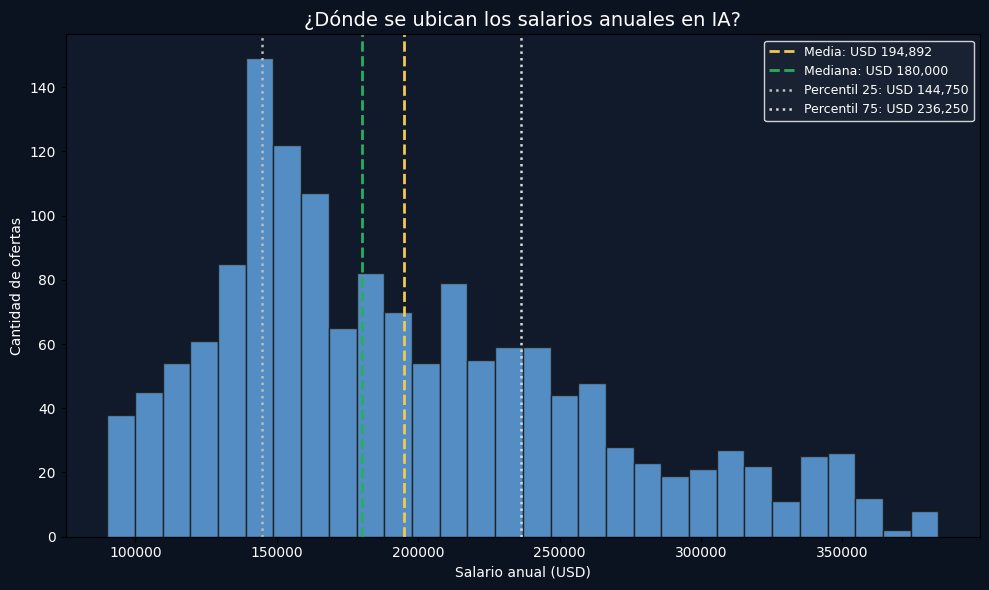

In [16]:
media = df["annual_salary_usd"].mean()
mediana = df["annual_salary_usd"].median()
q1 = df["annual_salary_usd"].quantile(0.25)
q3 = df["annual_salary_usd"].quantile(0.75)

plt.figure(figsize=(10, 6), facecolor="#0b1220")
ax = plt.gca()
ax.set_facecolor("#101a2b")

plt.hist(df["annual_salary_usd"], bins=30, color="#5b9bd5", edgecolor="#1f1f1f", alpha=0.9)

plt.axvline(media, color="#f2c94c", linestyle="--", linewidth=2, label=f"Media: USD {media:,.0f}")
plt.axvline(mediana, color="#27ae60", linestyle="--", linewidth=2, label=f"Mediana: USD {mediana:,.0f}")
plt.axvline(q1, color="#bdbdbd", linestyle=":", linewidth=1.8, label=f"Percentil 25: USD {q1:,.0f}")
plt.axvline(q3, color="#d9d9d9", linestyle=":", linewidth=1.8, label=f"Percentil 75: USD {q3:,.0f}")

plt.title("¿Dónde se ubican los salarios anuales en IA?", color="white", fontsize=14)
plt.xlabel("Salario anual (USD)", color="white")
plt.ylabel("Cantidad de ofertas", color="white")
plt.xticks(color="white")
plt.yticks(color="white")

legend = plt.legend(facecolor="#1c2536", edgecolor="white", fontsize=9)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

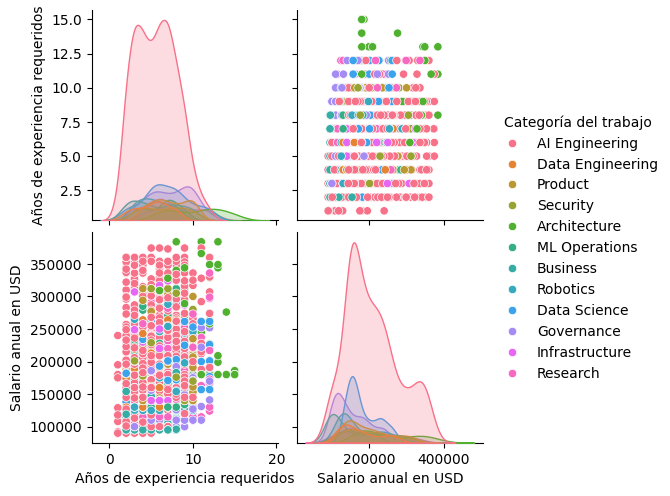

In [17]:
df_pair = df[[
    "years_of_experience",
    "annual_salary_usd",
    "job_category"
]].rename(columns={
    "years_of_experience": "Años de experiencia requeridos",
    "annual_salary_usd": "Salario anual en USD",
    "job_category": "Categoría del trabajo"
})

sns.pairplot(
    data=df_pair,
    hue="Categoría del trabajo"
)

plt.show()

## 5. Exploración de variables categóricas

In [18]:
vars_cat = [
    "job_title", "job_category", "city", "country", "remote_work",
    "company_size", "industry", "posting_year", "posting_month",
    "experience_level", "education_required", "salary_tier"
]

cardinalidad_df = pd.DataFrame({
    "Variable": vars_cat,
    "Cantidad de categorías únicas": [df[col].nunique() for col in vars_cat]
})

cardinalidad_df.sort_values("Cantidad de categorías únicas", ascending=False)

,Variable,Cantidad de categorías únicas
0,job_title,25
2,city,20
3,country,14
1,job_category,12
6,industry,12
8,posting_month,12
10,education_required,5
5,company_size,5
11,salary_tier,5
9,experience_level,4


In [19]:
moda_df = pd.DataFrame({
    "Variable": vars_cat,
    "Moda": [df[col].mode().iloc[0] if not df[col].mode().empty else np.nan for col in vars_cat],
    "Frecuencia de la moda": [df[col].value_counts().iloc[0] for col in vars_cat],
    "Proporción de la moda (%)": [round(df[col].value_counts(normalize=True).iloc[0] * 100, 2) for col in vars_cat]
})

moda_df.sort_values("Proporción de la moda (%)", ascending=False)

,Variable,Moda,Frecuencia de la moda,Proporción de la moda (%)
7,posting_year,2026,876,58.40
1,job_category,AI Engineering,736,49.07
4,remote_work,Hybrid,686,45.73
3,country,USA,515,34.33
11,salary_tier,Senior ($200-300k),467,31.13
9,experience_level,Entry (0-2 yrs),385,25.67
8,posting_month,2,361,24.07
10,education_required,Master's,316,21.07
5,company_size,Mid-size (501-5000),312,20.80
6,industry,Automotive,138,9.20


In [20]:
freq_job_category = pd.DataFrame({
    "Frecuencia absoluta": df["job_category"].value_counts(),
    "Frecuencia relativa (%)": round(df["job_category"].value_counts(normalize=True) * 100, 2)
})

freq_job_category

,Frecuencia absoluta,Frecuencia relativa (%)
job_category,,
AI Engineering,736,49.07
Data Science,127,8.47
Governance,122,8.13
Robotics,74,4.93
Product,70,4.67
Business,62,4.13
Infrastructure,55,3.67
Architecture,52,3.47
Data Engineering,51,3.40


In [21]:
freq_country = pd.DataFrame({
    "Frecuencia absoluta": df["country"].value_counts(),
    "Frecuencia relativa (%)": round(df["country"].value_counts(normalize=True) * 100, 2)
})

freq_country

,Frecuencia absoluta,Frecuencia relativa (%)
country,,
USA,515,34.33
UK,90,6.00
China,87,5.80
Canada,85,5.67
Global,82,5.47
Germany,81,5.40
Australia,78,5.20
Japan,76,5.07
Switzerland,76,5.07


In [22]:
relacion = (
    df.groupby(["job_category", "job_title"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["job_category", "frecuencia"], ascending=[True, False])
)

relacion

,job_category,job_title,frecuencia
5,AI Engineering,LLM Engineer,75
4,AI Engineering,Generative AI Engineer,71
9,AI Engineering,Prompt Engineer,71
7,AI Engineering,Multimodal AI Engineer,67
1,AI Engineering,AI Engineer,64
11,AI Engineering,Senior ML Engineer,64
3,AI Engineering,Deep Learning Engineer,58
0,AI Engineering,AI Agent Developer,57
6,AI Engineering,ML Engineer,55
8,AI Engineering,NLP Engineer,55


In [23]:
for col in ["is_senior", "is_remote_friendly", "is_llm_role"]:
    print(f"\nFrecuencias de {col}:")
    print(df[col].value_counts().sort_index())


Frecuencias de is_senior:
is_senior
0    755
1    745
Name: count, dtype: int64

Frecuencias de is_remote_friendly:
is_remote_friendly
0     369
1    1131
Name: count, dtype: int64

Frecuencias de is_llm_role:
is_llm_role
0    1173
1     327
Name: count, dtype: int64


## 6. Exploración de la relación entre numéricas y categóricas

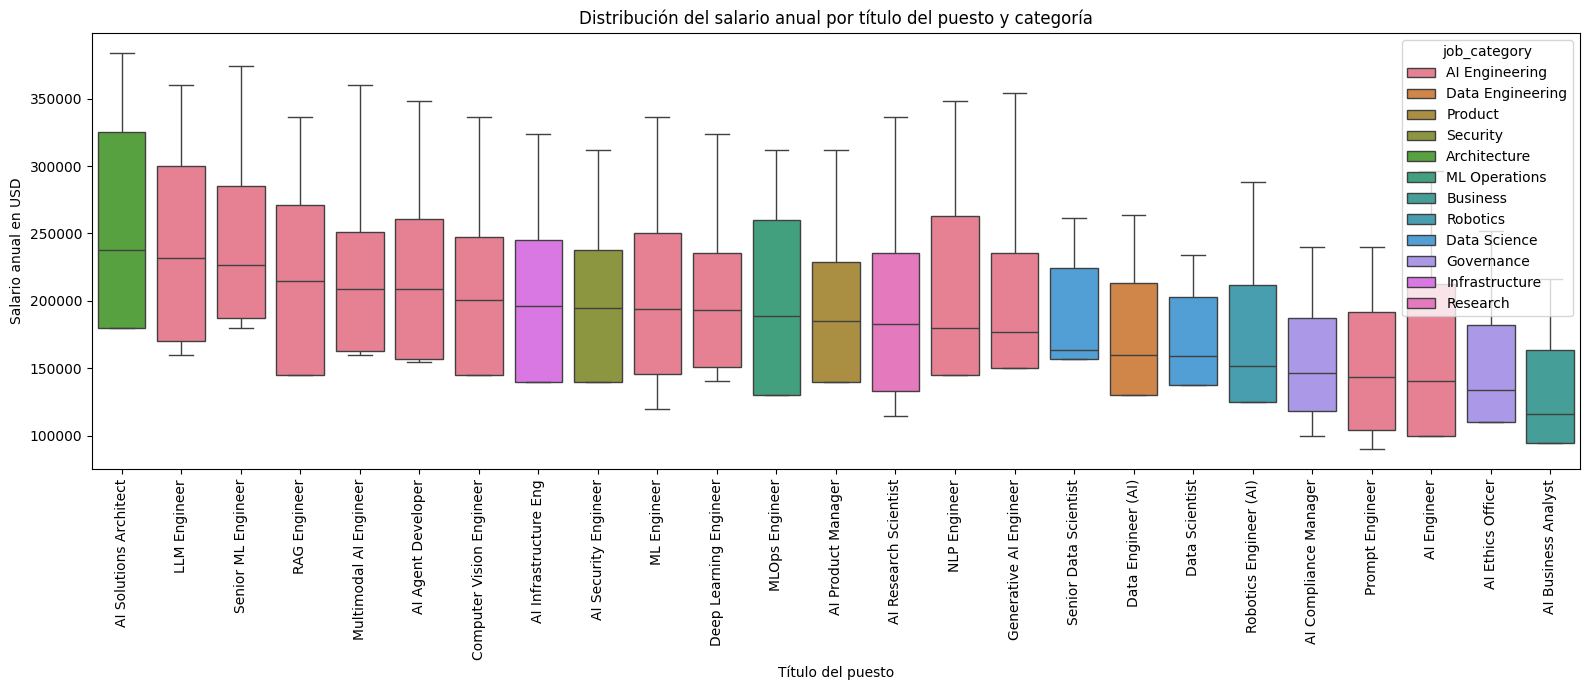

In [24]:
orden_job_title = (
    df.groupby("job_title")["annual_salary_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(16, 7))

sns.boxplot(
    data=df,
    x="job_title",
    y="annual_salary_usd",
    hue="job_category",
    order=orden_job_title,
    showfliers=False
)

plt.title("Distribución del salario anual por título del puesto y categoría")
plt.xlabel("Título del puesto")
plt.ylabel("Salario anual en USD")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

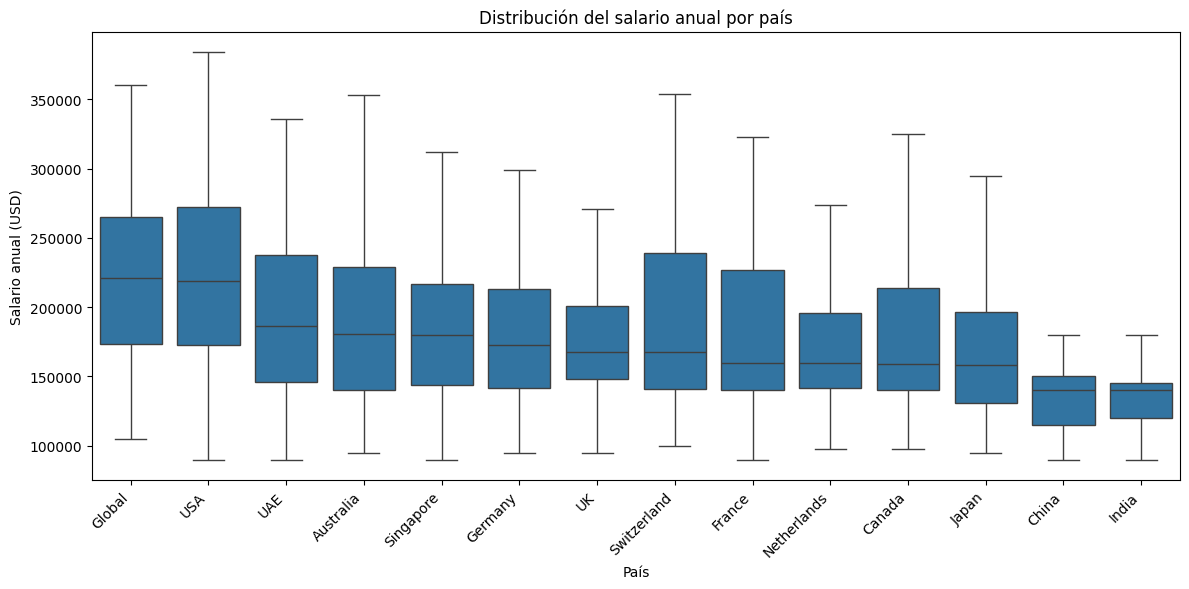

In [25]:
orden_paises = (
    df.groupby("country")["annual_salary_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="country",
    y="annual_salary_usd",
    order=orden_paises,
    showfliers=False
)

plt.title("Distribución del salario anual por país")
plt.xlabel("País")
plt.ylabel("Salario anual (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

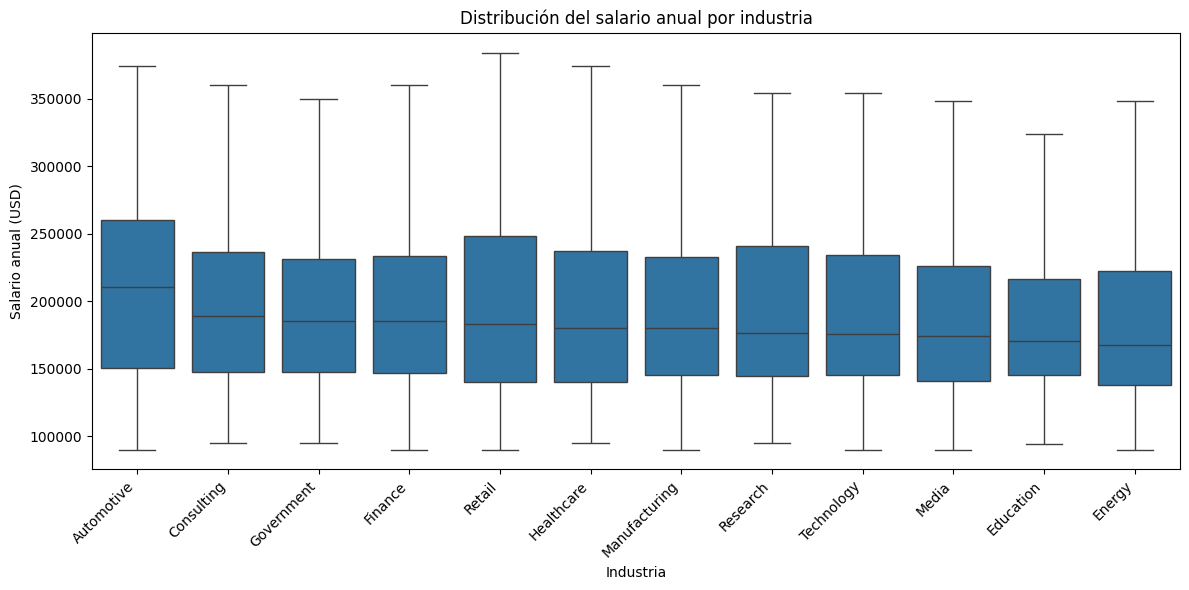

In [26]:
orden_industrias = (
    df.groupby("industry")["annual_salary_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="industry",
    y="annual_salary_usd",
    order=orden_industrias,
    showfliers=False
)

plt.title("Distribución del salario anual por industria")
plt.xlabel("Industria")
plt.ylabel("Salario anual (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

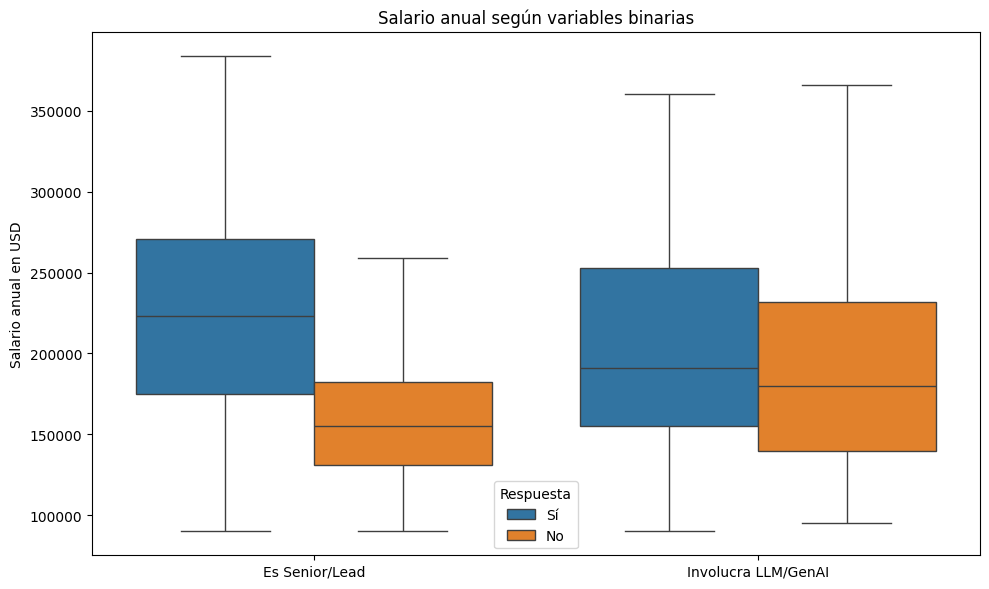

In [27]:
vars_bin = ["is_senior", "is_llm_role"]

df_bin_salario = df.melt(
    id_vars="annual_salary_usd",
    value_vars=vars_bin,
    var_name="Variable binaria",
    value_name="Valor"
)

df_bin_salario["Variable binaria"] = df_bin_salario["Variable binaria"].replace({
    "is_senior": "Es Senior/Lead",
    "is_llm_role": "Involucra LLM/GenAI"
})

df_bin_salario["Valor"] = df_bin_salario["Valor"].replace({
    0: "No",
    1: "Sí"
})

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_bin_salario,
    x="Variable binaria",
    y="annual_salary_usd",
    hue="Valor",
    showfliers=False
)

plt.title("Salario anual según variables binarias")
plt.xlabel("")
plt.ylabel("Salario anual en USD")
plt.legend(title="Respuesta")
plt.tight_layout()
plt.show()

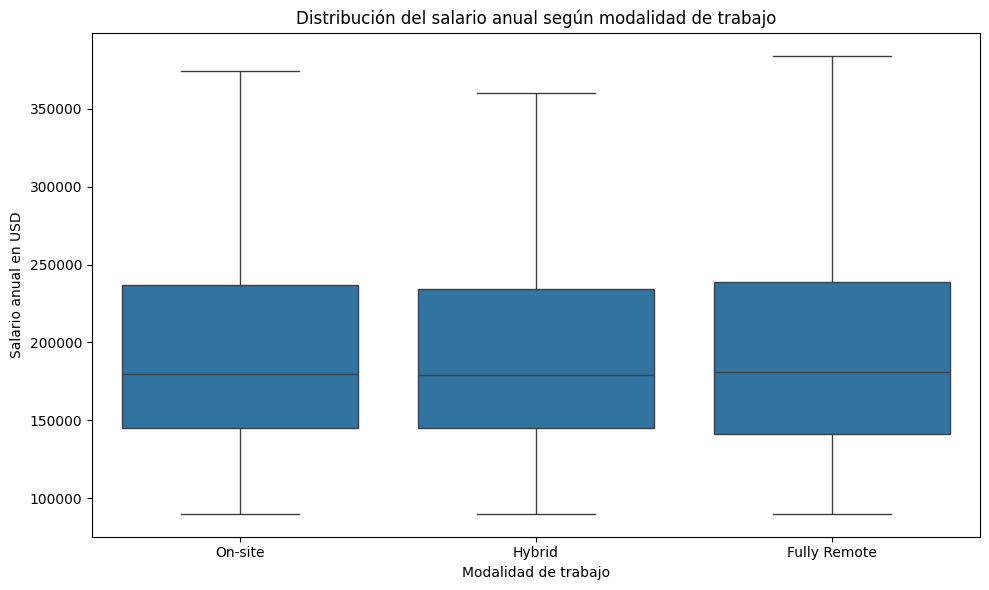

In [28]:
orden_remote = ["On-site", "Hybrid", "Fully Remote"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="remote_work",
    y="annual_salary_usd",
    order=orden_remote,
    showfliers=False
)

plt.title("Distribución del salario anual según modalidad de trabajo")
plt.xlabel("Modalidad de trabajo")
plt.ylabel("Salario anual en USD")
plt.tight_layout()
plt.show()

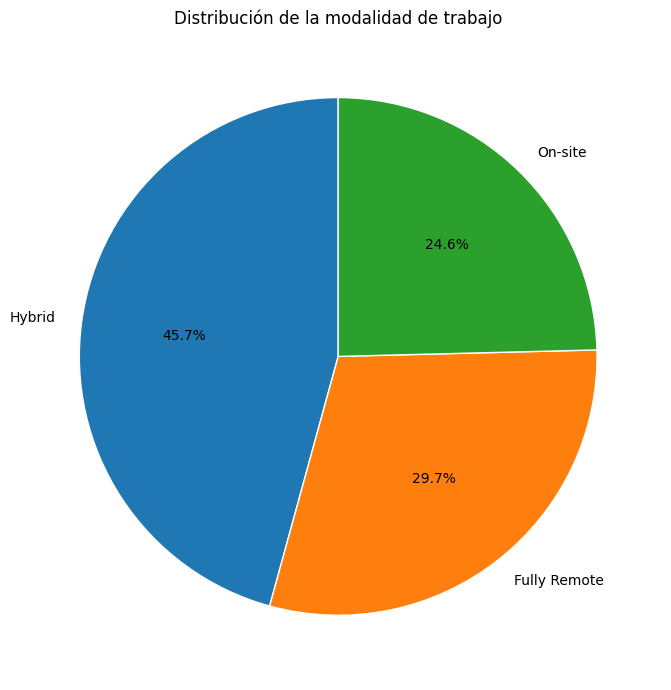

In [29]:
plt.figure(figsize=(7, 7))

df["remote_work"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Distribución de la modalidad de trabajo")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Outliers

#### 7.1 Método basado en el rango intercuartil

In [30]:
df_out = df[["annual_salary_usd"]].copy()

In [31]:
Q1 = df_out.quantile(0.25)
Q3 = df_out.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_out < (Q1 - 1.5 * IQR)) | (df_out > (Q3 + 1.5 * IQR))

print(f"Outliers en annual_salary_usd: <{Q1['annual_salary_usd'] - 1.5 * IQR['annual_salary_usd']:.2f} o >{Q3['annual_salary_usd'] + 1.5 * IQR['annual_salary_usd']:.2f}")

Outliers en annual_salary_usd: <7500.00 o >373500.00


In [32]:
outliers_iqr

,annual_salary_usd
0,False
1,False
2,False
3,False
4,False
...,...
1495,False
1496,False
1497,False
1498,False


In [33]:
outliers_iqr["annual_salary_usd"].sum()

np.int64(8)

In [34]:
df.loc[outliers_iqr["annual_salary_usd"], ["job_id", "job_title", "job_category", "annual_salary_usd"]]

,job_id,job_title,job_category,annual_salary_usd
83,AIJOB0084,Senior ML Engineer,AI Engineering,374400.0
647,AIJOB0648,Senior ML Engineer,AI Engineering,374400.0
822,AIJOB0823,AI Solutions Architect,Architecture,384000.0
843,AIJOB0844,Senior ML Engineer,AI Engineering,374400.0
896,AIJOB0897,AI Solutions Architect,Architecture,384000.0
944,AIJOB0945,Senior ML Engineer,AI Engineering,374400.0
992,AIJOB0993,Senior ML Engineer,AI Engineering,374400.0
1374,AIJOB1375,AI Solutions Architect,Architecture,384000.0


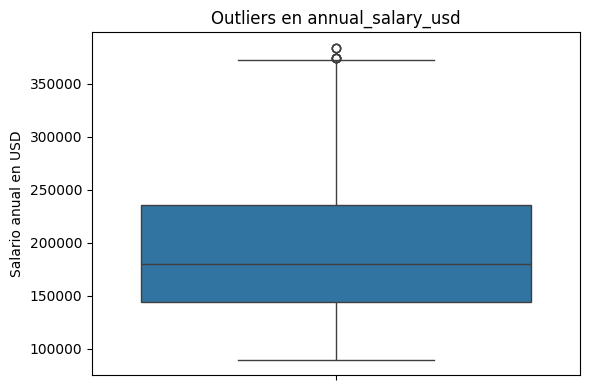

In [35]:
plt.figure(figsize=(6, 4))

sns.boxplot(y=df_out["annual_salary_usd"])
plt.title("Outliers en annual_salary_usd")
plt.ylabel("Salario anual en USD")

plt.tight_layout()
plt.show()

#### 7.2 Metodo de desvío estándar

In [36]:
mean = df_out.mean()
std = df_out.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_out < (mean - 3 * std)) | (df_out > (mean + 3 * std))

print(f"Outliers en annual_salary_usd: <{mean['annual_salary_usd'] - 3 * std['annual_salary_usd']:.2f} o >{mean['annual_salary_usd'] + 3 * std['annual_salary_usd']:.2f}")

Outliers en annual_salary_usd: <-4628.47 o >394412.47


In [37]:
outliers_std["annual_salary_usd"].sum()

np.int64(0)

In [38]:
df.loc[outliers_std["annual_salary_usd"], ["job_id", "job_title", "job_category", "annual_salary_usd"]]

,job_id,job_title,job_category,annual_salary_usd


#### 7.3 Gráfico

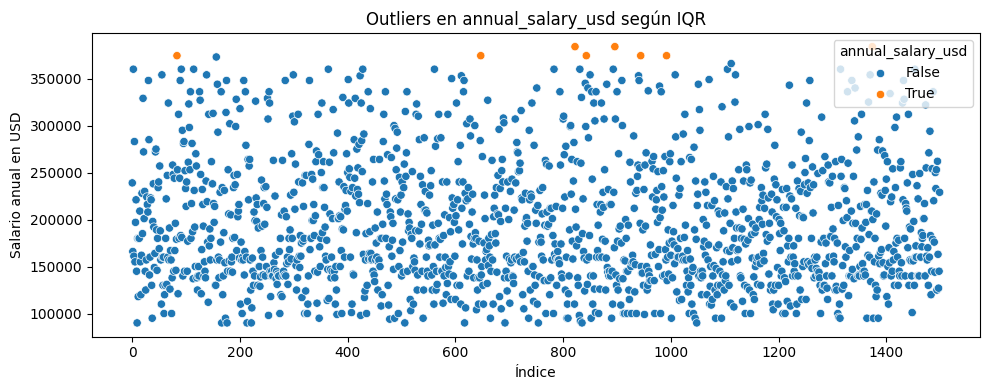

In [39]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    x=df_out.index,
    y=df_out["annual_salary_usd"],
    hue=outliers_iqr["annual_salary_usd"]
)

plt.title("Outliers en annual_salary_usd según IQR")
plt.xlabel("Índice")
plt.ylabel("Salario anual en USD")
plt.tight_layout()
plt.show()

#### 7.4 Conclusión outliers

Por el método basado en rango intercuartil se detectaron 8 outliers, mientras que por el método clásico de desvio estándar no se detectaron outliers.

## 8. Conclusiones


El dataset contiene 1.500 filas y 25 columnas, y en general está en buenas condiciones para el análisis porque no presenta nulos ni duplicados. La mayor parte de las ofertas se concentra en AI Engineering, con USA como país más frecuente y una fuerte presencia de modalidades hybrid y perfiles remote-friendly. En las variables numéricas, el salario anual promedio ronda los USD 194.892, el 50% se distribuye entreUSD 144.750 y USD 236.250, y los salarios más altos detectados corresponden al puesto de AI Solutions Architect. Por último, el análisis de outliers encontró 8 casos en annual_salary_usd con el método de rango intercuartil, pero ninguno con el método de desvío estándar.